# Homework 03: Learning Curves and Training Workflow

**Points:** 85

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. It’s a large, mildly imbalanced multi-class benchmark commonly used to compare classical ML and deep learning on tabular data.

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework. 

In [1]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam, AdamW

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# reproducibility

random_seed = 42
os.environ["PYTHONHASHSEED"] = str(random_seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"   # partial on Apple MPS but helps

random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed) 

# utility code

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


In [2]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [3]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training. 

In [4]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        shuffle=False,                        # important for strict reproducibility
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

In [5]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class

min_count = 1000


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {2: 1000, 0: 1000, 4: 1000, 5: 1000, 1: 1000, 3: 1000, 6: 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={2: 600, 1: 600, 0: 600, 3: 600, 5: 600, 4: 600, 6: 600}
val  : total=1400, per-class={1: 200, 6: 200, 5: 200, 4: 200, 3: 200, 2: 200, 0: 200}
test : total=1400, per-class={0: 200, 6: 200, 2: 200, 3: 200, 4: 200, 5: 200, 1: 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which build models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters. 

In [6]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained. 

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, 
                             activation=act, 
                             kernel_regularizer=regularizers.l2(l2_lambda))
                     )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [7]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),                              
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

**We call `build_model` as shown here:**

In [8]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

----------------

### Baseline Model Architecture

Problems 1–5 will use the following baseline model structure, implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Baseline Model -- relu



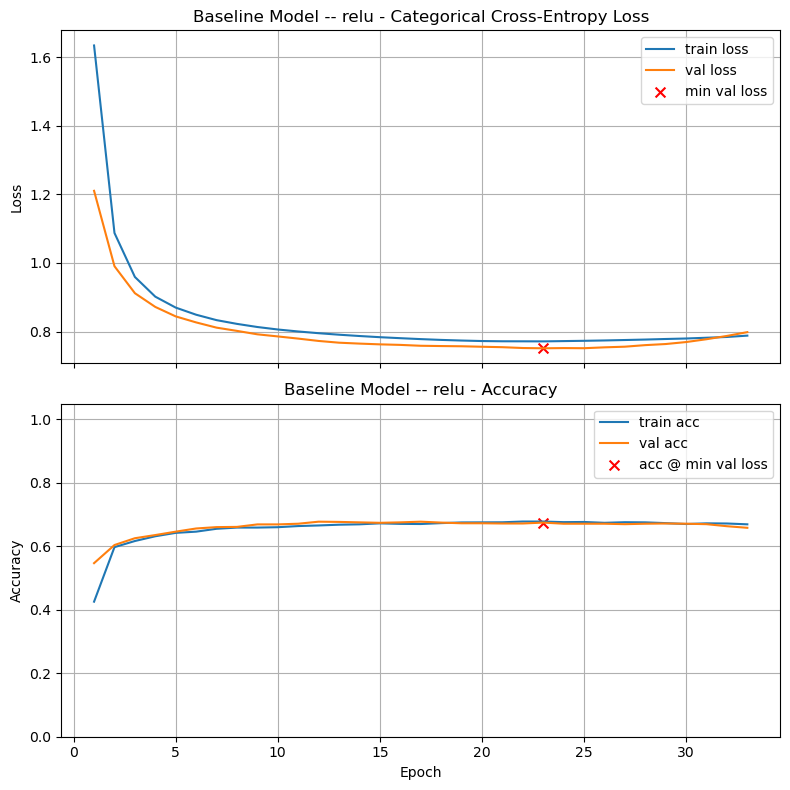

Final Training Loss:            0.7881
Final Training Accuracy:        0.6695
Final Validation Loss:          0.7983
Final Validation Accuracy:      0.6586
Minimum Validation Loss:        0.7513 (Epoch 23)
Validation Accuracy @ Min Loss: 0.6750

Test Loss: 0.7977
Test Accuracy: 0.6593

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:21


In [9]:
model_baseline = build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.0,0.0) ], n_classes)   
train_and_test(model_baseline, title = f"Baseline Model -- relu")


Baseline Model -- sigmoid



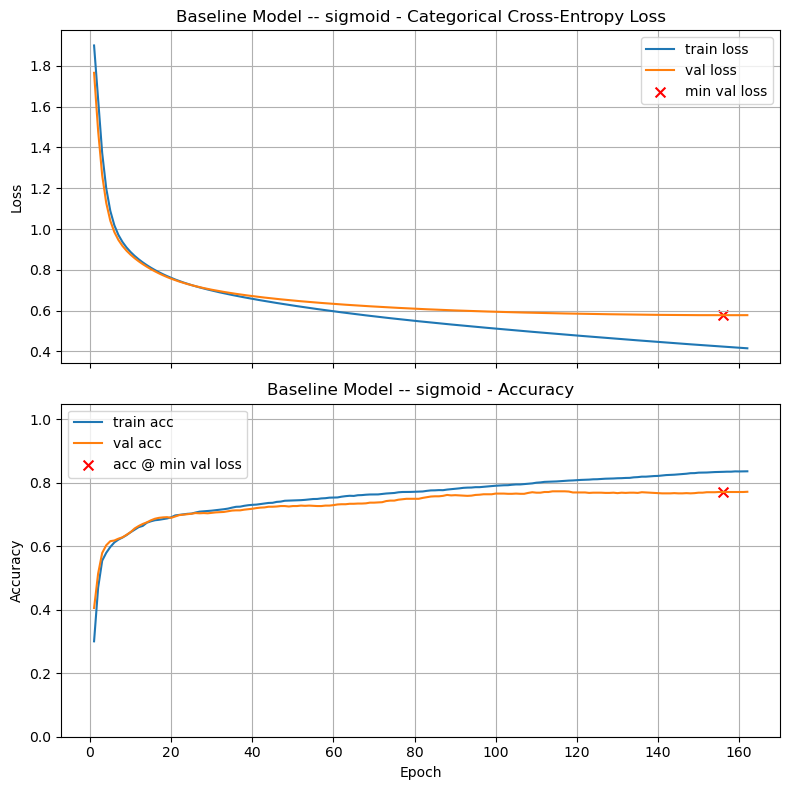

Final Training Loss:            0.4150
Final Training Accuracy:        0.8367
Final Validation Loss:          0.5775
Final Validation Accuracy:      0.7721
Minimum Validation Loss:        0.5773 (Epoch 156)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.5779
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:01:41


In [10]:
model_baseline = build_model(X_train.shape[1], [ (64,'sigmoid',0.0,0.0), (32,'sigmoid',0.0,0.0) ], n_classes)   
train_and_test(model_baseline, title = f"Baseline Model -- sigmoid")


Baseline Model -- tanh



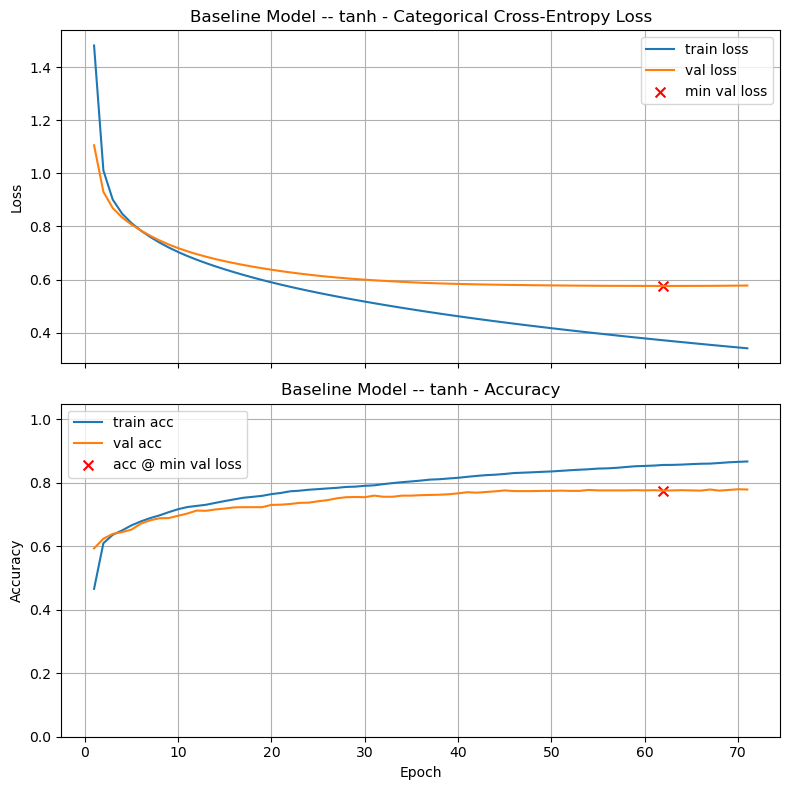

Final Training Loss:            0.3407
Final Training Accuracy:        0.8676
Final Validation Loss:          0.5773
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.5757 (Epoch 62)
Validation Accuracy @ Min Loss: 0.7757

Test Loss: 0.5673
Test Accuracy: 0.7607

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:44


In [11]:
model_baseline = build_model(X_train.shape[1], [ (64,'tanh',0.0,0.0), (32,'tanh',0.0,0.0) ], n_classes)   
train_and_test(model_baseline, title = f"Baseline Model -- tanh")

### Graded Questions

In [12]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

a1a = ...             # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)
a1a = 2

In [13]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 2


In [14]:
# Set a1b to the validation accuracy found by this best activation function

a1b = 0.0             # Replace 0.0 with your answer
a1b = 0.7721

In [15]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7721


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**



Baseline Model -- lr: 0.001



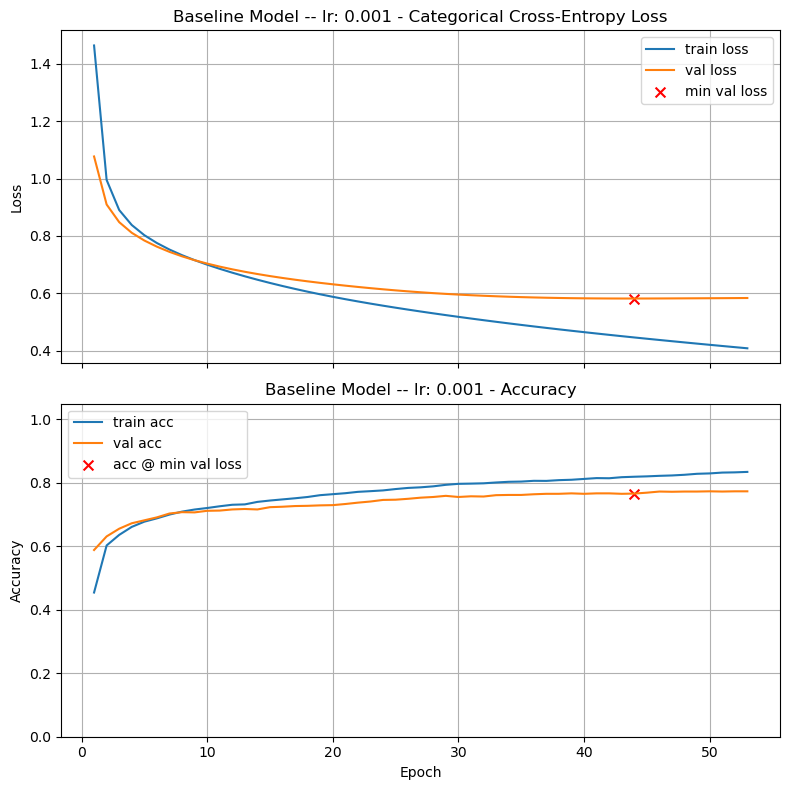

Final Training Loss:            0.4085
Final Training Accuracy:        0.8348
Final Validation Loss:          0.5838
Final Validation Accuracy:      0.7736
Minimum Validation Loss:        0.5820 (Epoch 44)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.5852
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.010000

Execution Time: 00:00:33

Baseline Model -- lr: 0.0005



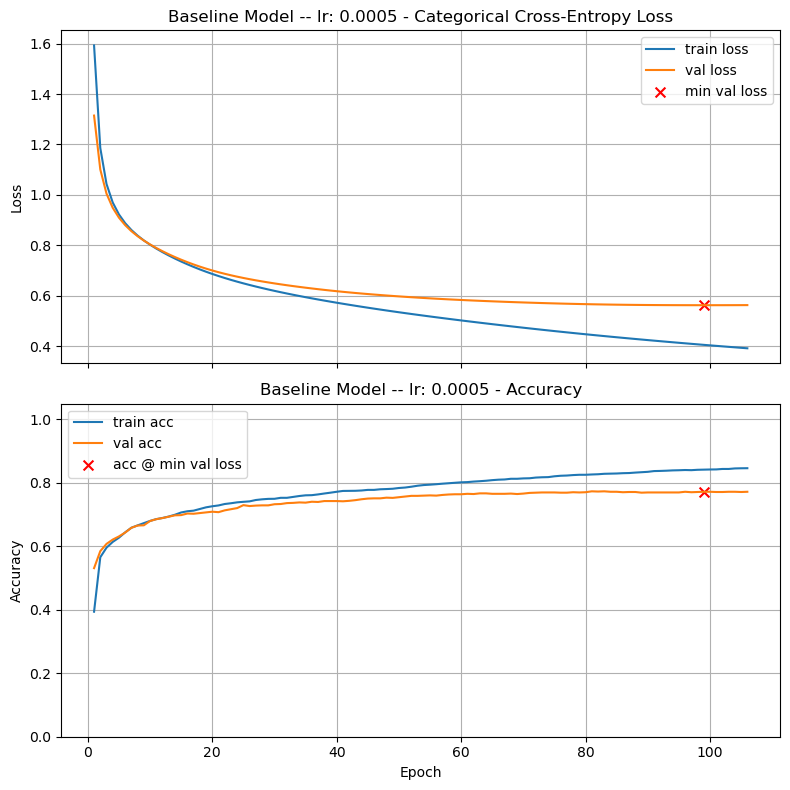

Final Training Loss:            0.3913
Final Training Accuracy:        0.8464
Final Validation Loss:          0.5626
Final Validation Accuracy:      0.7721
Minimum Validation Loss:        0.5623 (Epoch 99)
Validation Accuracy @ Min Loss: 0.7721

Test Loss: 0.5683
Test Accuracy: 0.7629

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:01:05

Baseline Model -- lr: 0.0001



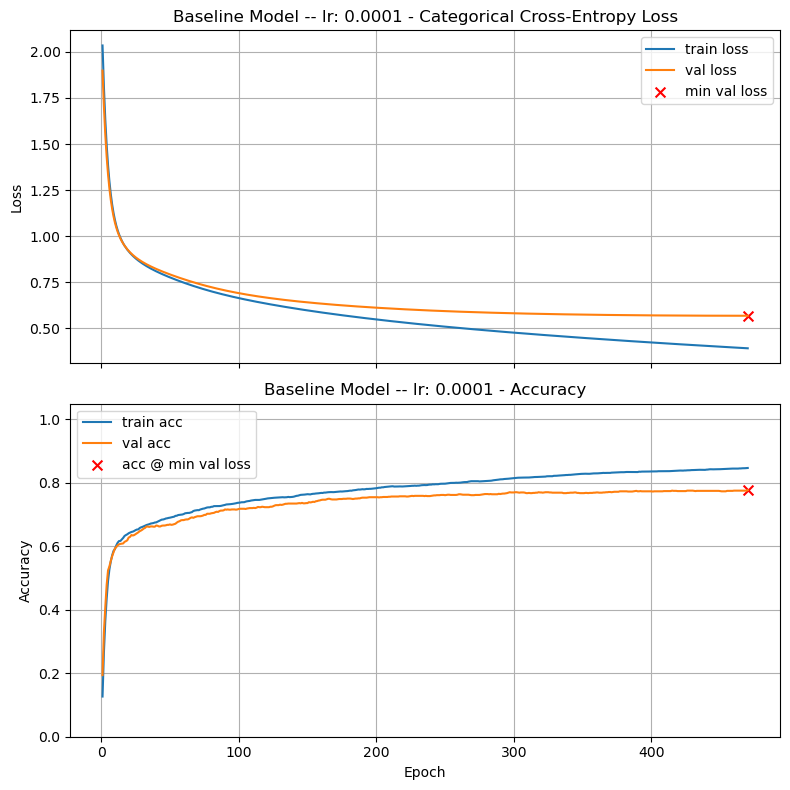

Final Training Loss:            0.3918
Final Training Accuracy:        0.8471
Final Validation Loss:          0.5683
Final Validation Accuracy:      0.7771
Minimum Validation Loss:        0.5683 (Epoch 470)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.5738
Test Accuracy: 0.7607

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:04:49

Baseline Model -- lr: 5e-05



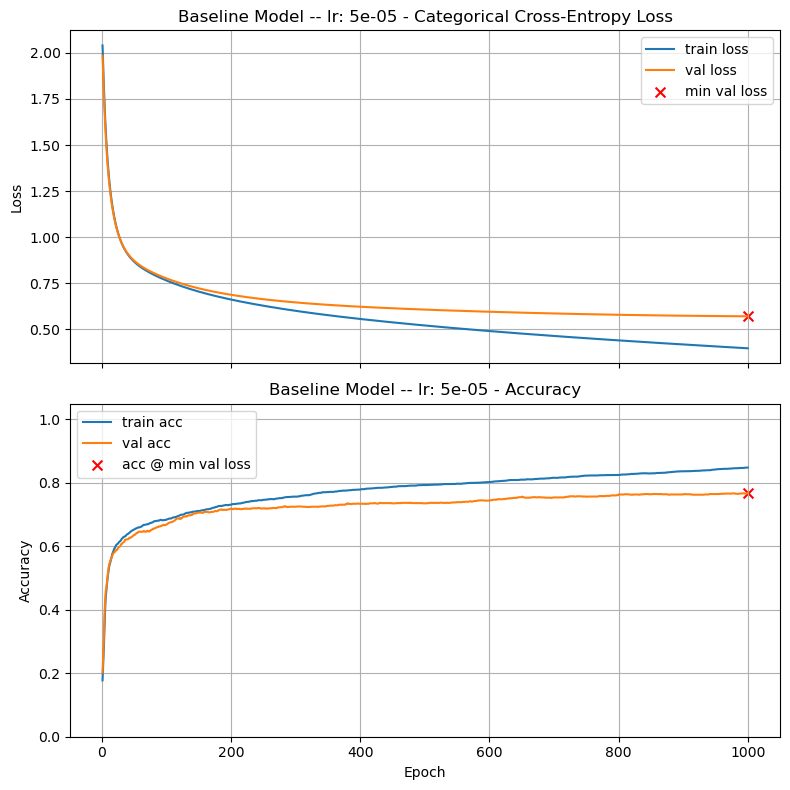

Final Training Loss:            0.3978
Final Training Accuracy:        0.8486
Final Validation Loss:          0.5713
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.5713 (Epoch 1000)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.5643
Test Accuracy: 0.7643

Validation-Test Gap (accuracy): 0.002143

Execution Time: 00:10:17

Baseline Model -- lr: 1e-05



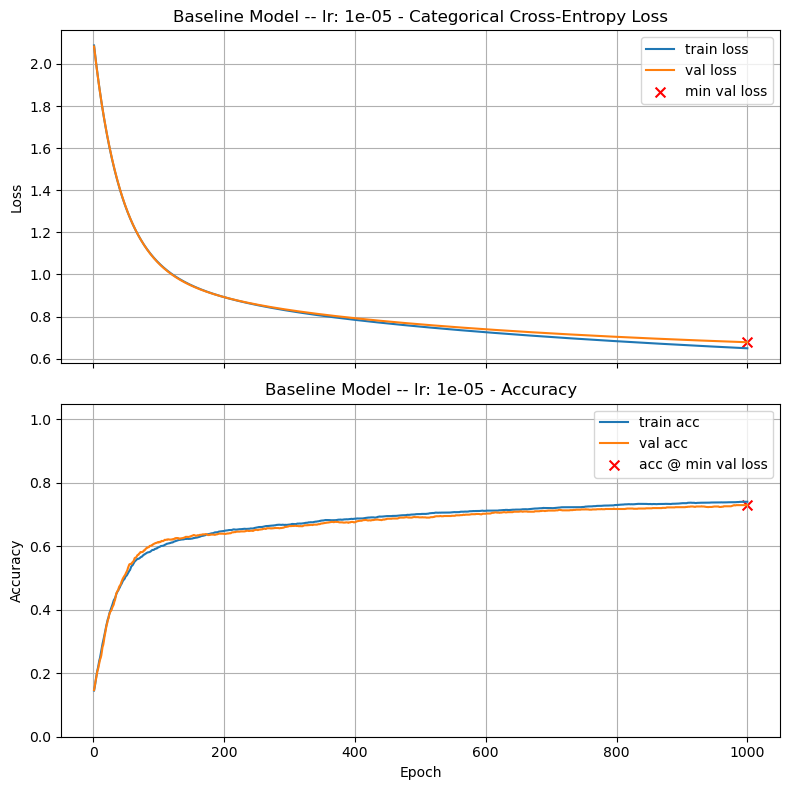

Final Training Loss:            0.6495
Final Training Accuracy:        0.7407
Final Validation Loss:          0.6782
Final Validation Accuracy:      0.7300
Minimum Validation Loss:        0.6782 (Epoch 1000)
Validation Accuracy @ Min Loss: 0.7300

Test Loss: 0.7010
Test Accuracy: 0.7186

Validation-Test Gap (accuracy): 0.011429

Execution Time: 00:10:13


In [16]:
for lr in [1e-3,5e-4,1e-4,5e-5,1e-5]:

    model_baseline = build_model(X_train.shape[1], [ (64,'tanh',0.0,0.0), (32,'tanh',0.0,0.0) ], n_classes)
    
    train_and_test(model_baseline, epochs = 1000, lr_schedule = lr, title = f"Baseline Model -- lr: {lr}")

#### Graded Questions

In [17]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 0.0           # Replace 0.0 with your answer
a2a = 0.0005 

In [18]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.6f}') 

a2a = 0.000500


In [19]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = 0.0             # Replace 0.0 with your answer
a2b = 0.7693

In [20]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7693


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Baseline Model -- dropout: (0.0, 0.3)



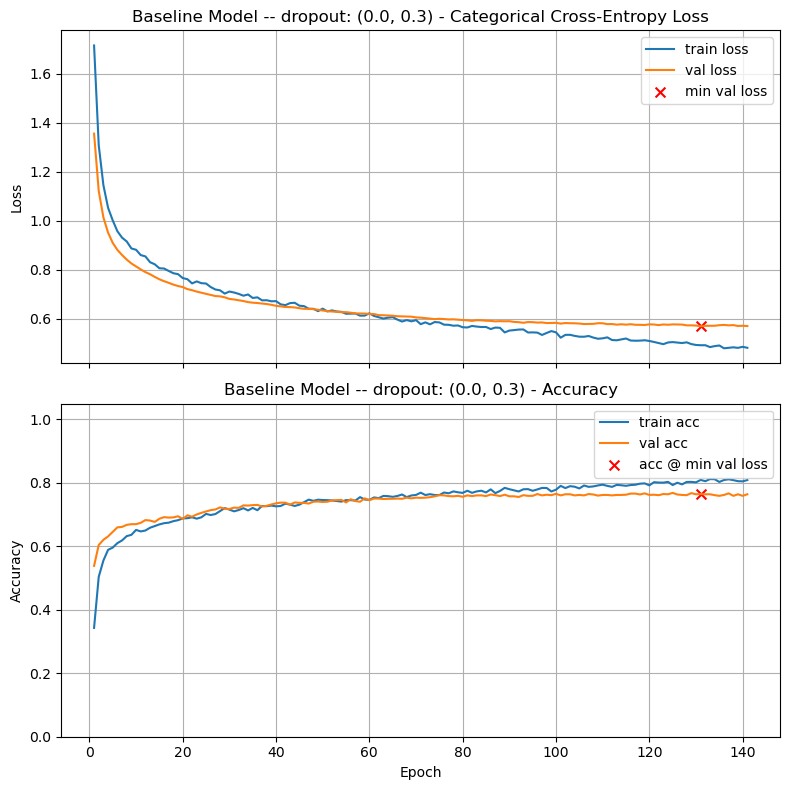

Final Training Loss:            0.4814
Final Training Accuracy:        0.8090
Final Validation Loss:          0.5702
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.5692 (Epoch 131)
Validation Accuracy @ Min Loss: 0.7650

Test Loss: 0.6085
Test Accuracy: 0.7507

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:01:35

Baseline Model -- dropout: (0.0, 0.4)



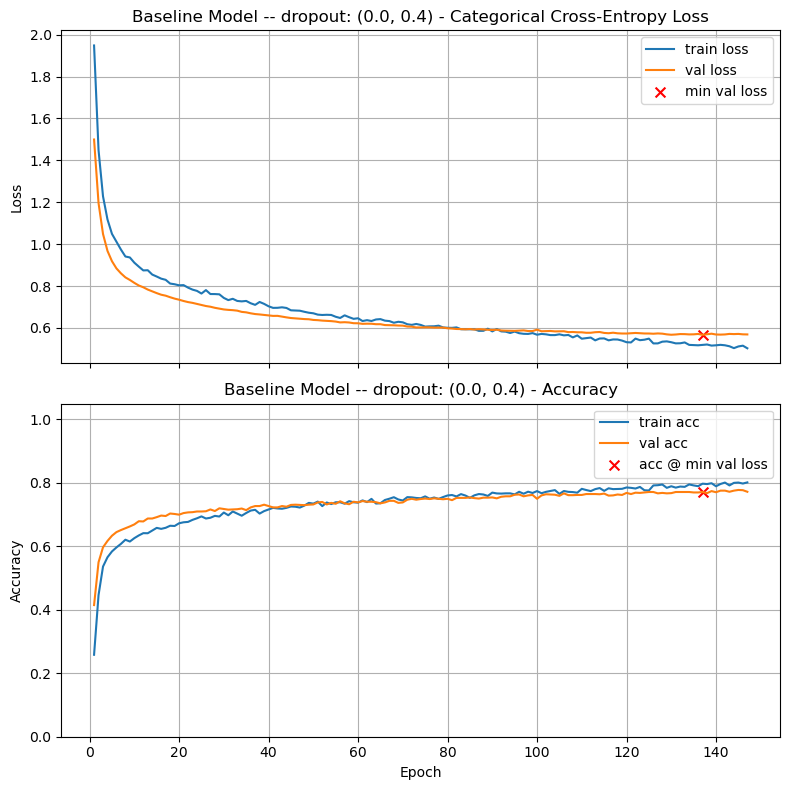

Final Training Loss:            0.5029
Final Training Accuracy:        0.8017
Final Validation Loss:          0.5690
Final Validation Accuracy:      0.7721
Minimum Validation Loss:        0.5672 (Epoch 137)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6010
Test Accuracy: 0.7550

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:01:39

Baseline Model -- dropout: (0.0, 0.5)



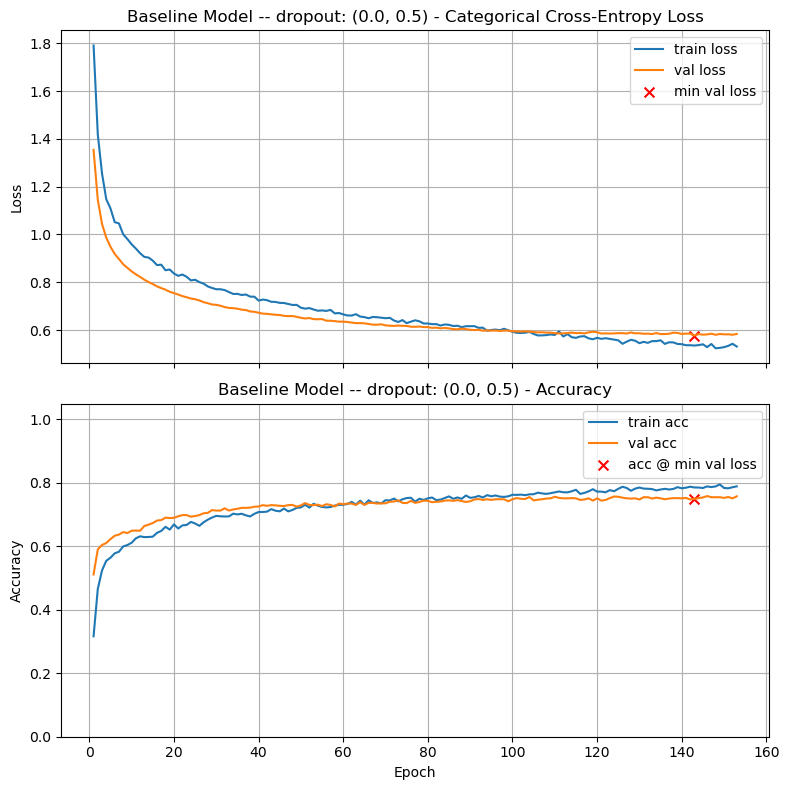

Final Training Loss:            0.5310
Final Training Accuracy:        0.7893
Final Validation Loss:          0.5834
Final Validation Accuracy:      0.7579
Minimum Validation Loss:        0.5770 (Epoch 143)
Validation Accuracy @ Min Loss: 0.7500

Test Loss: 0.6100
Test Accuracy: 0.7529

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:01:43

Baseline Model -- dropout: (0.1, 0.3)



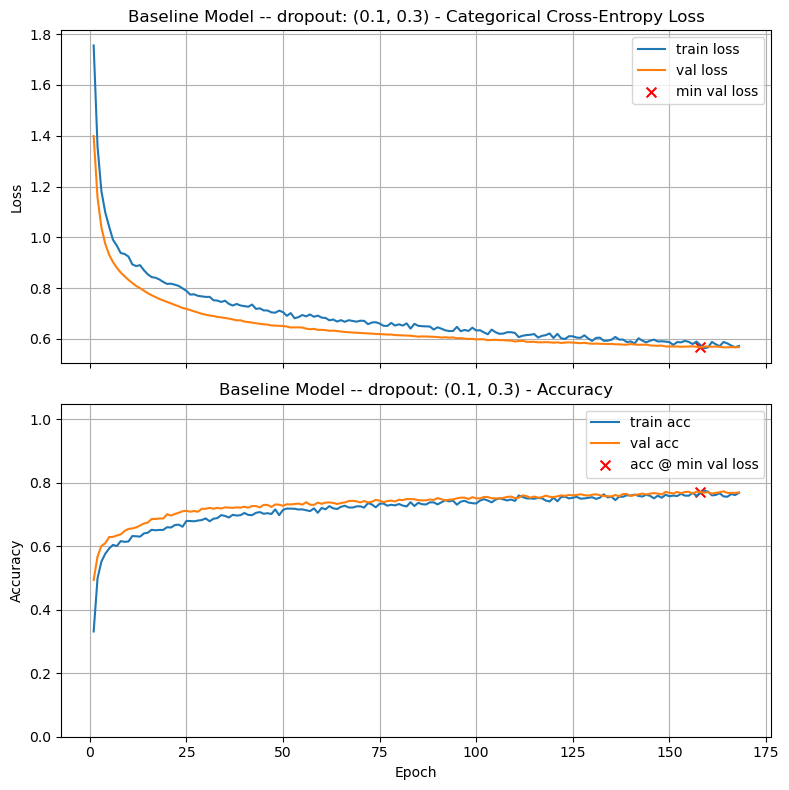

Final Training Loss:            0.5720
Final Training Accuracy:        0.7690
Final Validation Loss:          0.5671
Final Validation Accuracy:      0.7700
Minimum Validation Loss:        0.5663 (Epoch 158)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6085
Test Accuracy: 0.7514

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:01:56

Baseline Model -- dropout: (0.1, 0.4)



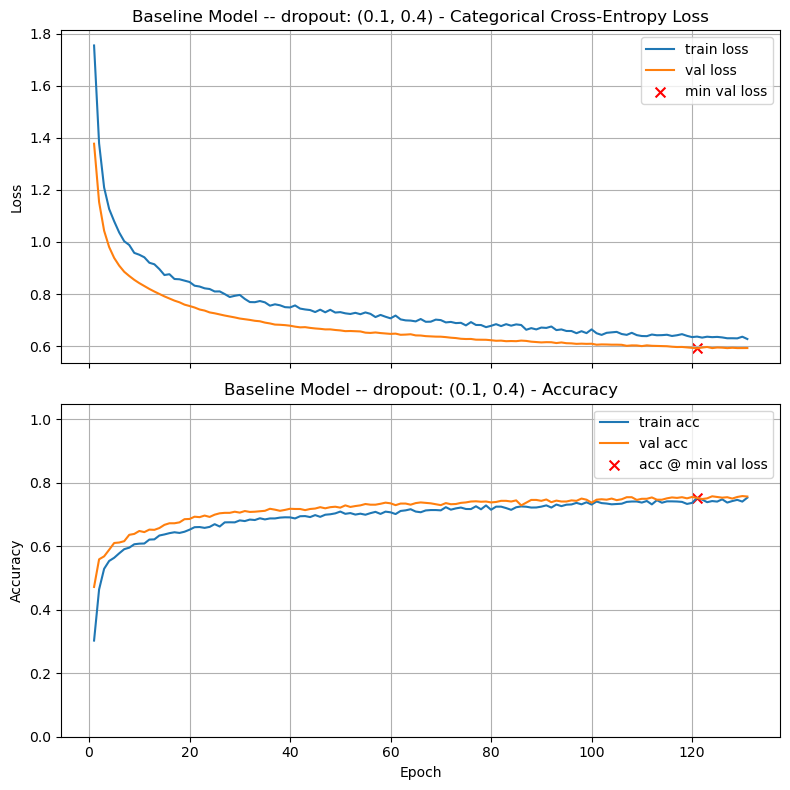

Final Training Loss:            0.6271
Final Training Accuracy:        0.7536
Final Validation Loss:          0.5924
Final Validation Accuracy:      0.7571
Minimum Validation Loss:        0.5915 (Epoch 121)
Validation Accuracy @ Min Loss: 0.7529

Test Loss: 0.6289
Test Accuracy: 0.7314

Validation-Test Gap (accuracy): 0.021429

Execution Time: 00:01:32

Baseline Model -- dropout: (0.1, 0.5)



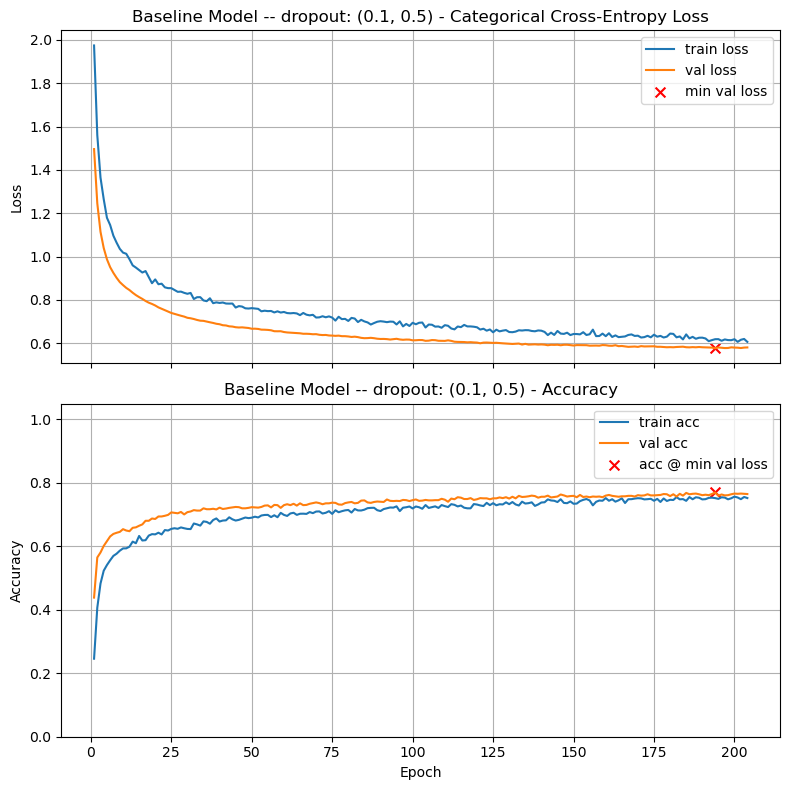

Final Training Loss:            0.6063
Final Training Accuracy:        0.7524
Final Validation Loss:          0.5807
Final Validation Accuracy:      0.7650
Minimum Validation Loss:        0.5768 (Epoch 194)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.6139
Test Accuracy: 0.7500

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:02:22

Baseline Model -- dropout: (0.2, 0.3)



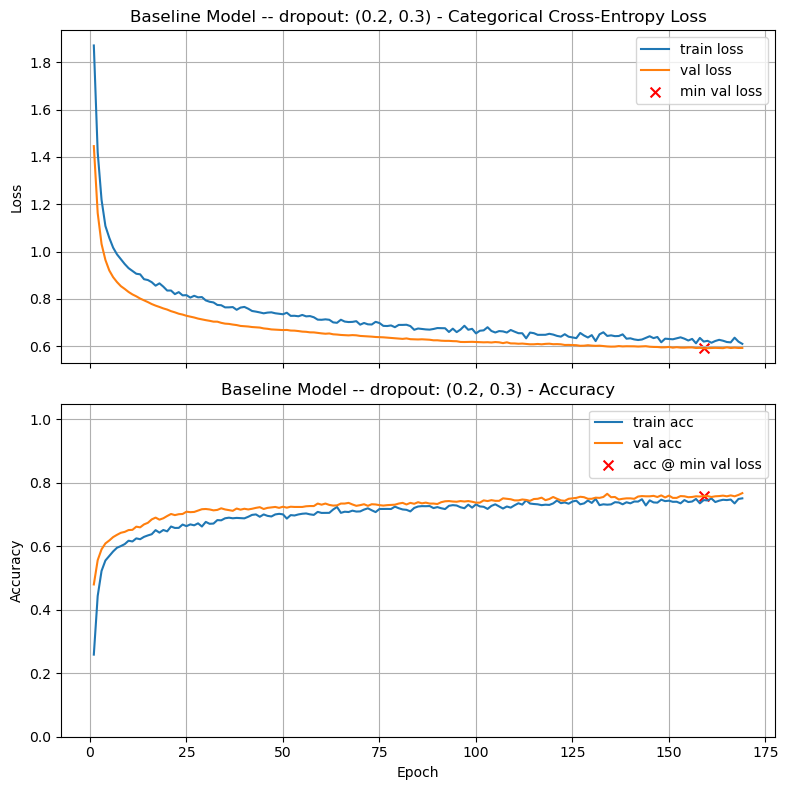

Final Training Loss:            0.6095
Final Training Accuracy:        0.7514
Final Validation Loss:          0.5921
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.5907 (Epoch 159)
Validation Accuracy @ Min Loss: 0.7586

Test Loss: 0.6185
Test Accuracy: 0.7357

Validation-Test Gap (accuracy): 0.022857

Execution Time: 00:01:57

Baseline Model -- dropout: (0.2, 0.4)



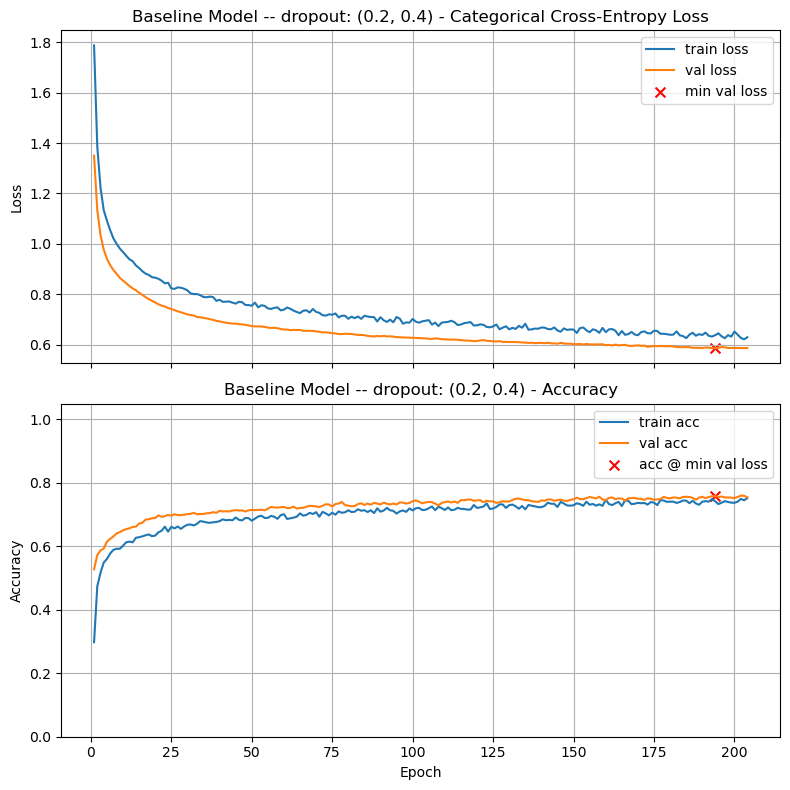

Final Training Loss:            0.6289
Final Training Accuracy:        0.7524
Final Validation Loss:          0.5860
Final Validation Accuracy:      0.7550
Minimum Validation Loss:        0.5850 (Epoch 194)
Validation Accuracy @ Min Loss: 0.7586

Test Loss: 0.6114
Test Accuracy: 0.7443

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:02:22

Baseline Model -- dropout: (0.2, 0.5)



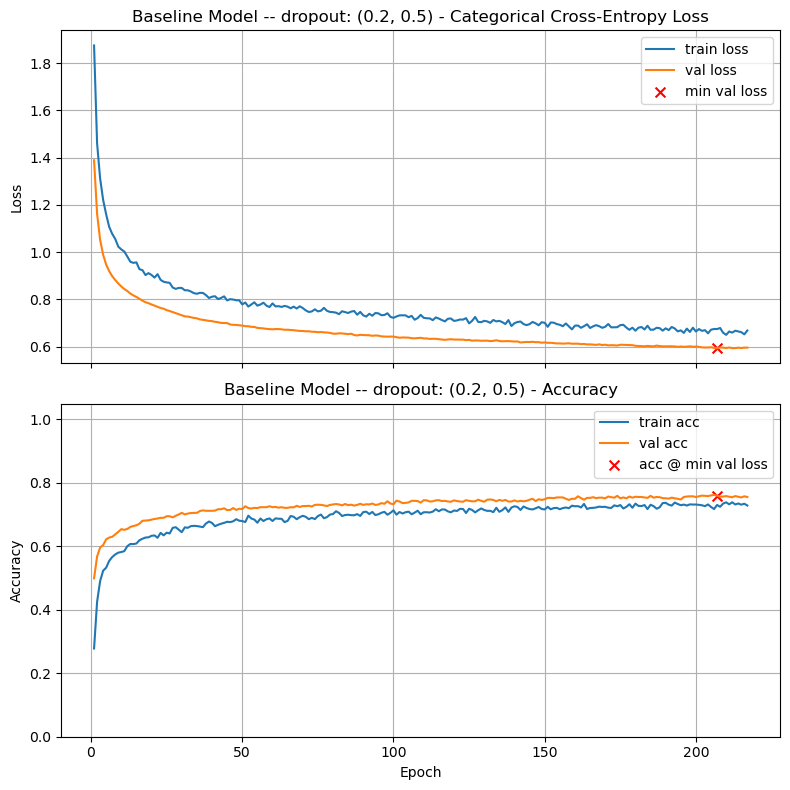

Final Training Loss:            0.6679
Final Training Accuracy:        0.7288
Final Validation Loss:          0.5953
Final Validation Accuracy:      0.7557
Minimum Validation Loss:        0.5926 (Epoch 207)
Validation Accuracy @ Min Loss: 0.7600

Test Loss: 0.6285
Test Accuracy: 0.7457

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:02:30


In [21]:
for do1 in [0.0,0.1,0.2]:
    for do2 in [0.3,0.4,0.5]:
        model_do = build_model(X_train.shape[1], [ (64,'tanh',0.0,do1), (32,'tanh',0.0,do2) ], n_classes)
    
        train_and_test(model_do, lr_schedule = 0.0005, title = f"Baseline Model -- dropout: {(do1,do2)}")

In [22]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best validation accuracy at the epoch of minimum validation loss

a3a = (0.0,0.0)             # Replace (0.0,0.0) with your answer
a3a = (0.1,0.5) 

In [23]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 

a3a = (0.1, 0.5)


In [24]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = 0.0             # Replace 0.0 with your answer
a3b = 0.7757

In [25]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7757


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simple by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Baseline Model -- L2: (0.0001, 0.0001)



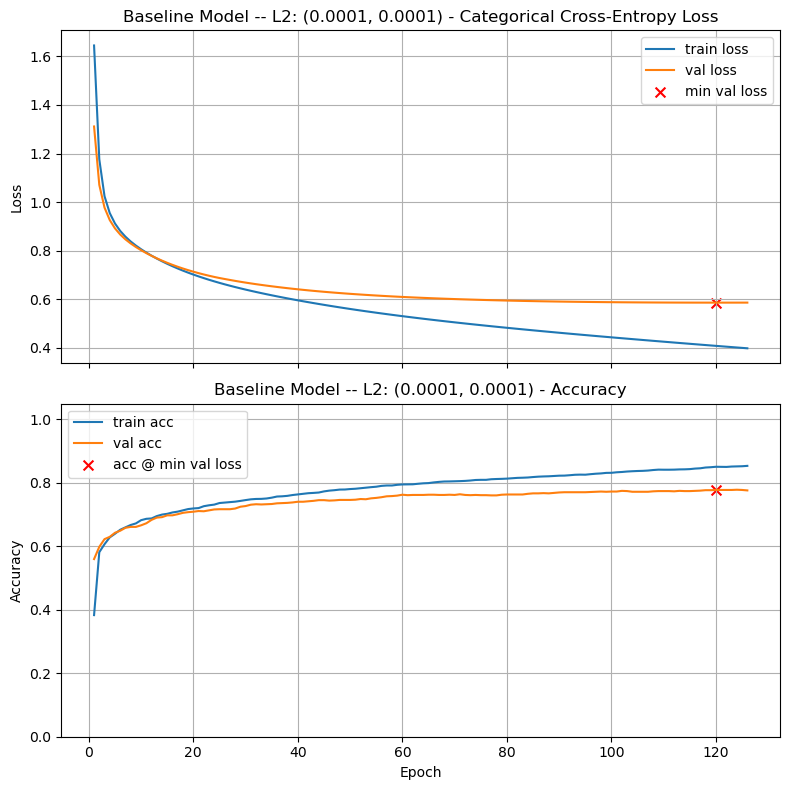

Final Training Loss:            0.3987
Final Training Accuracy:        0.8538
Final Validation Loss:          0.5867
Final Validation Accuracy:      0.7764
Minimum Validation Loss:        0.5866 (Epoch 120)
Validation Accuracy @ Min Loss: 0.7779

Test Loss: 0.6111
Test Accuracy: 0.7564

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:01:21

Baseline Model -- L2: (0.001, 0.001)



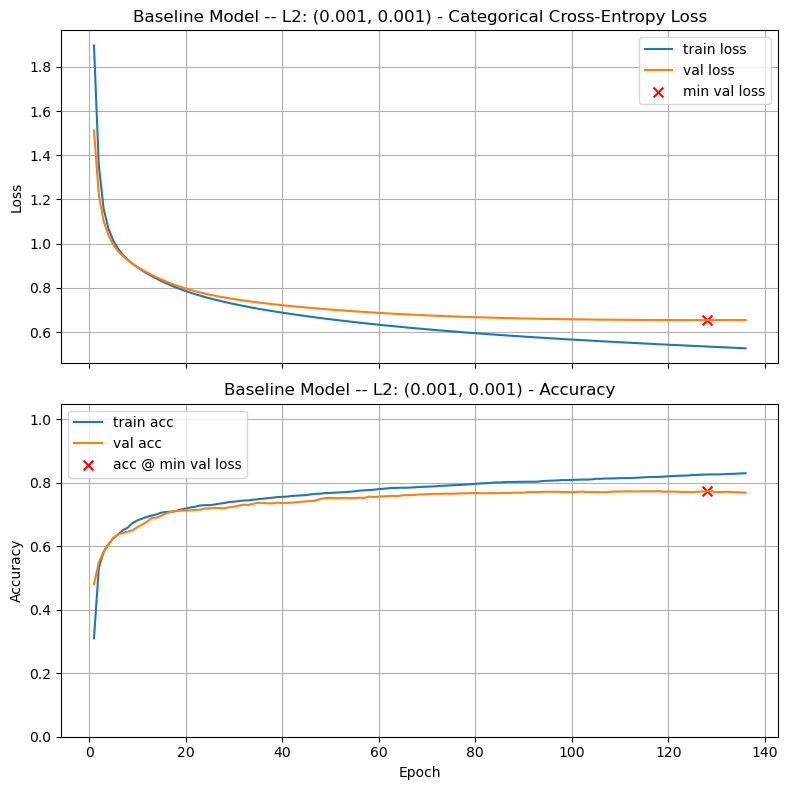

Final Training Loss:            0.5266
Final Training Accuracy:        0.8305
Final Validation Loss:          0.6544
Final Validation Accuracy:      0.7693
Minimum Validation Loss:        0.6541 (Epoch 128)
Validation Accuracy @ Min Loss: 0.7736

Test Loss: 0.6684
Test Accuracy: 0.7671

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:01:27

Baseline Model -- L2: (0.01, 0.01)



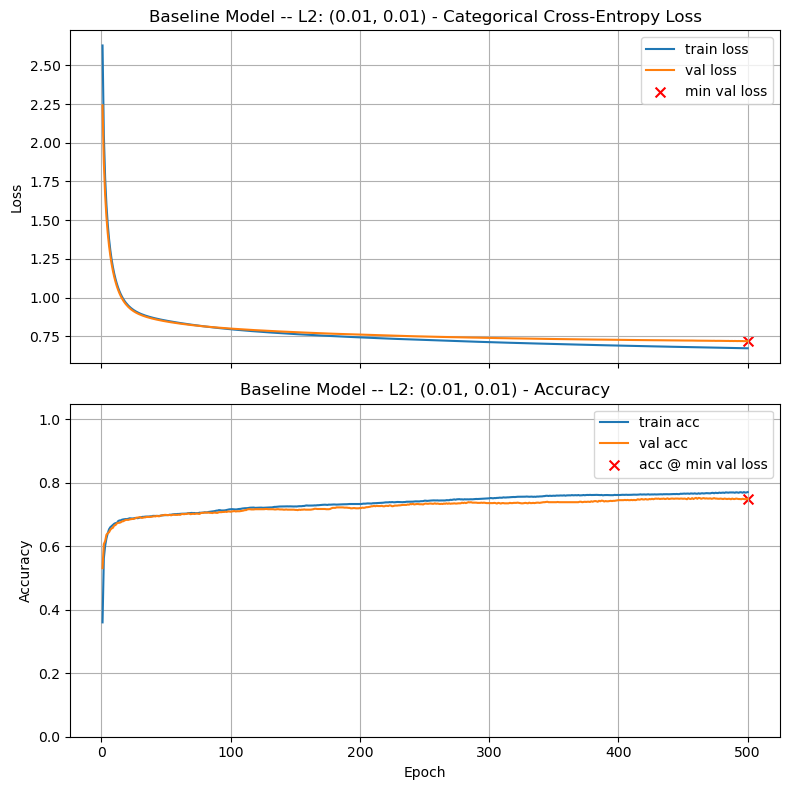

Final Training Loss:            0.6721
Final Training Accuracy:        0.7712
Final Validation Loss:          0.7178
Final Validation Accuracy:      0.7500
Minimum Validation Loss:        0.7178 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7500

Test Loss: 0.7499
Test Accuracy: 0.7350

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:05:15

Baseline Model -- L2: (0.0001, 0.001)



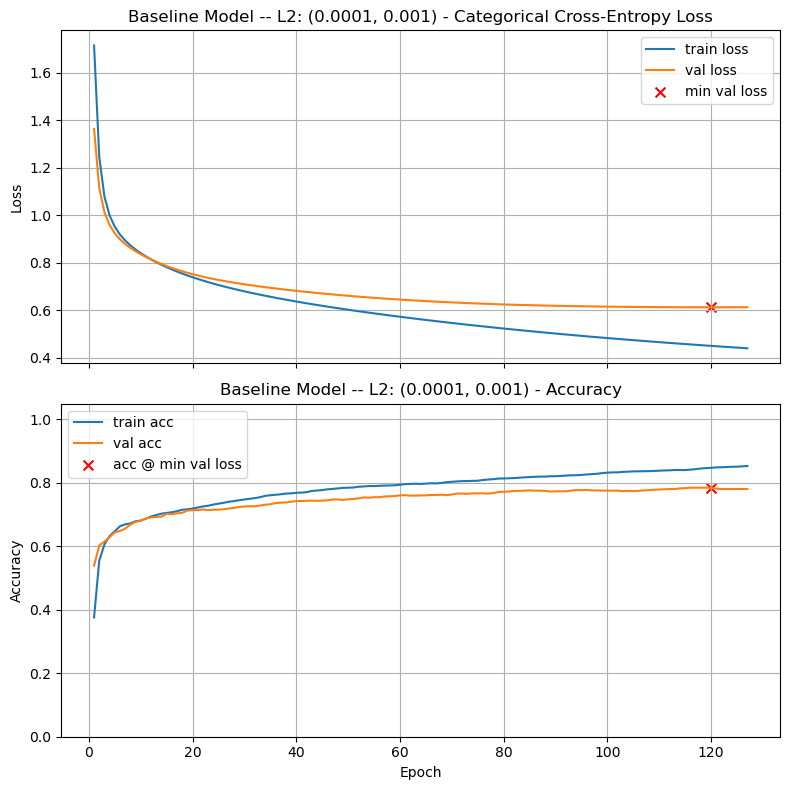

Final Training Loss:            0.4399
Final Training Accuracy:        0.8536
Final Validation Loss:          0.6127
Final Validation Accuracy:      0.7807
Minimum Validation Loss:        0.6125 (Epoch 120)
Validation Accuracy @ Min Loss: 0.7843

Test Loss: 0.6380
Test Accuracy: 0.7571

Validation-Test Gap (accuracy): 0.027857

Execution Time: 00:01:20


In [26]:
for l21 in [1e-4, 1e-3, 1e-2]:

        model_l2 = build_model(X_train.shape[1], [ (64,'tanh',l21,0.0), (32,'tanh',l21,0.0) ], n_classes)
    
        train_and_test(model_l2, lr_schedule = 0.0005, title = f"Baseline Model -- L2: {(l21,l21)}")


model_l2 = build_model(X_train.shape[1], [ (64,'tanh',1e-4,0.0), (32,'tanh',1e-3,0.0) ], n_classes)
    
train_and_test(model_l2, lr_schedule = 0.0005, title = f"Baseline Model -- L2: {(1e-4,1e-3)}")


Baseline Model -- L2: (0.0001, 0.001)



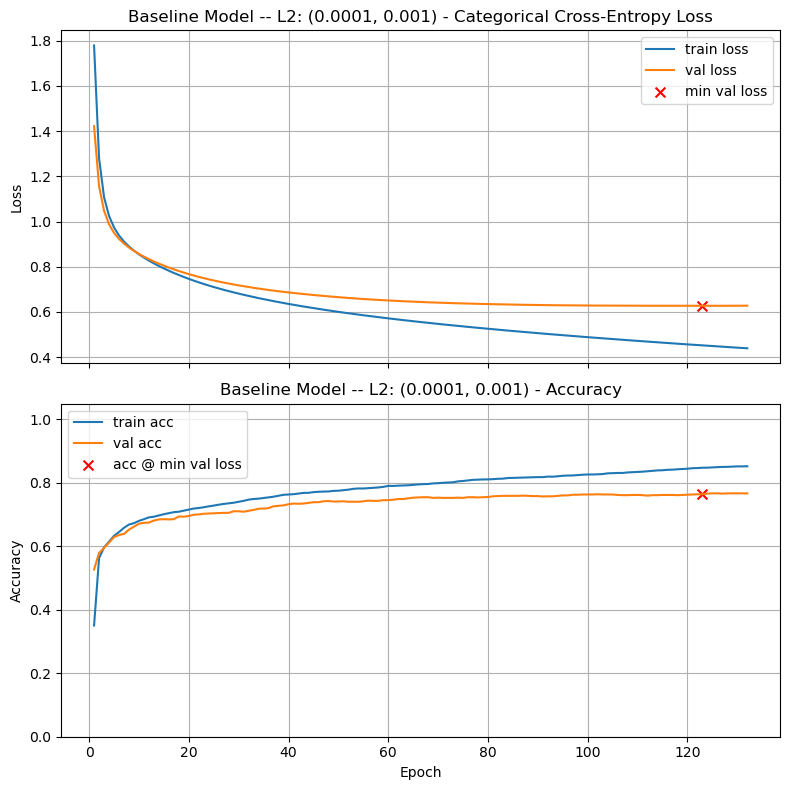

Final Training Loss:            0.4391
Final Training Accuracy:        0.8526
Final Validation Loss:          0.6276
Final Validation Accuracy:      0.7671
Minimum Validation Loss:        0.6271 (Epoch 123)
Validation Accuracy @ Min Loss: 0.7643

Test Loss: 0.6270
Test Accuracy: 0.7543

Validation-Test Gap (accuracy): 0.010000

Execution Time: 00:01:23


In [27]:
model_l2 = build_model(X_train.shape[1], [ (64,'tanh',1e-4,0.0), (32,'tanh',1e-3,0.0) ], n_classes)
    
train_and_test(model_l2, lr_schedule = 0.0005, title = f"Baseline Model -- L2: {(1e-4,1e-3)}")

In [28]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of dropout rates for the two hidden layers which provided the best validation accuracy at the epoch of minimum validation loss

a4a = (0.0,0.0)             # Replace (0.0,0.0) with your answer
a4a = (0.0001,0.001)

In [29]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a}') 

a4a = (0.0001, 0.001)


In [30]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = 0.0             # Replace 0.0 with your answer
a4b = 0.7814

In [31]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.7814


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combined with L2 Regularization.  
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.




Both Model -- Do: (0.1,0.5) L2: (0.0001, 0.0001)



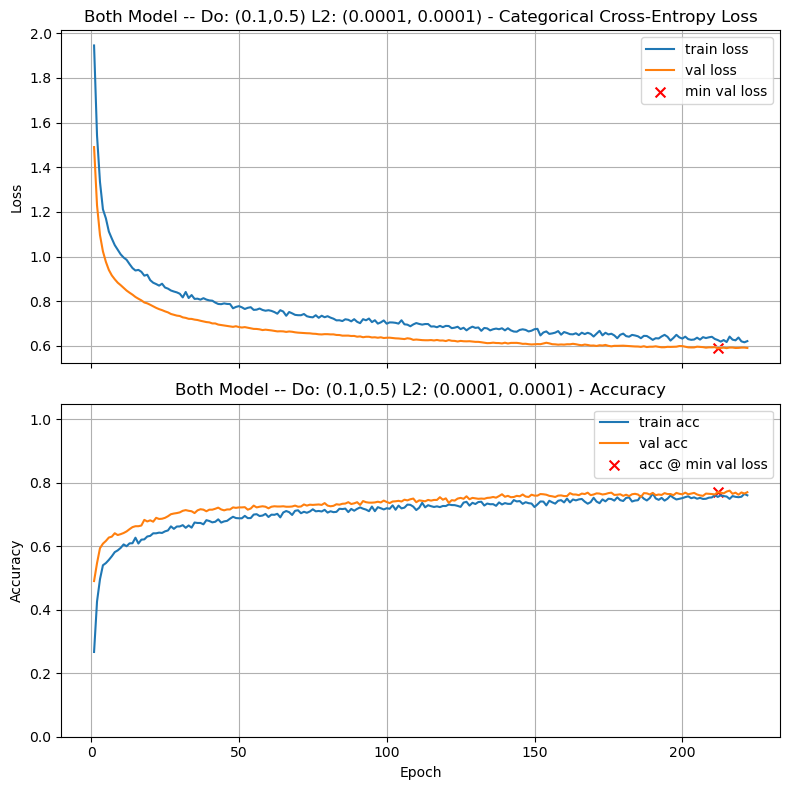

Final Training Loss:            0.6214
Final Training Accuracy:        0.7610
Final Validation Loss:          0.5908
Final Validation Accuracy:      0.7707
Minimum Validation Loss:        0.5893 (Epoch 212)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6215
Test Accuracy: 0.7621

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:02:37

Both Model -- Do: (0.1,0.5) L2: (0.001, 0.001)



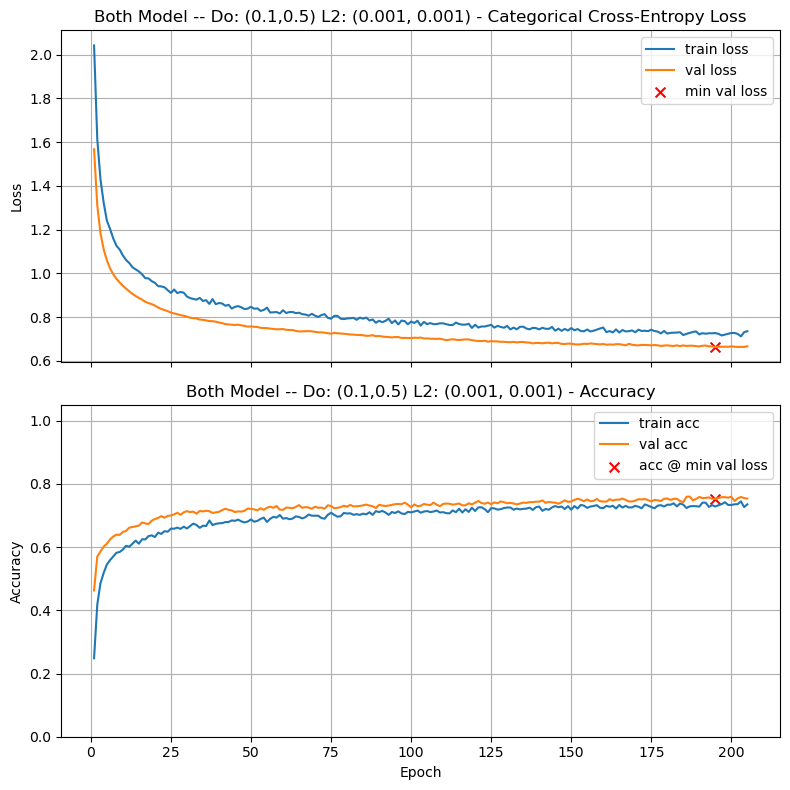

Final Training Loss:            0.7353
Final Training Accuracy:        0.7352
Final Validation Loss:          0.6662
Final Validation Accuracy:      0.7536
Minimum Validation Loss:        0.6626 (Epoch 195)
Validation Accuracy @ Min Loss: 0.7521

Test Loss: 0.7003
Test Accuracy: 0.7429

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:02:25

Both Model -- Do: (0.1,0.5) L2: (0.01, 0.01)



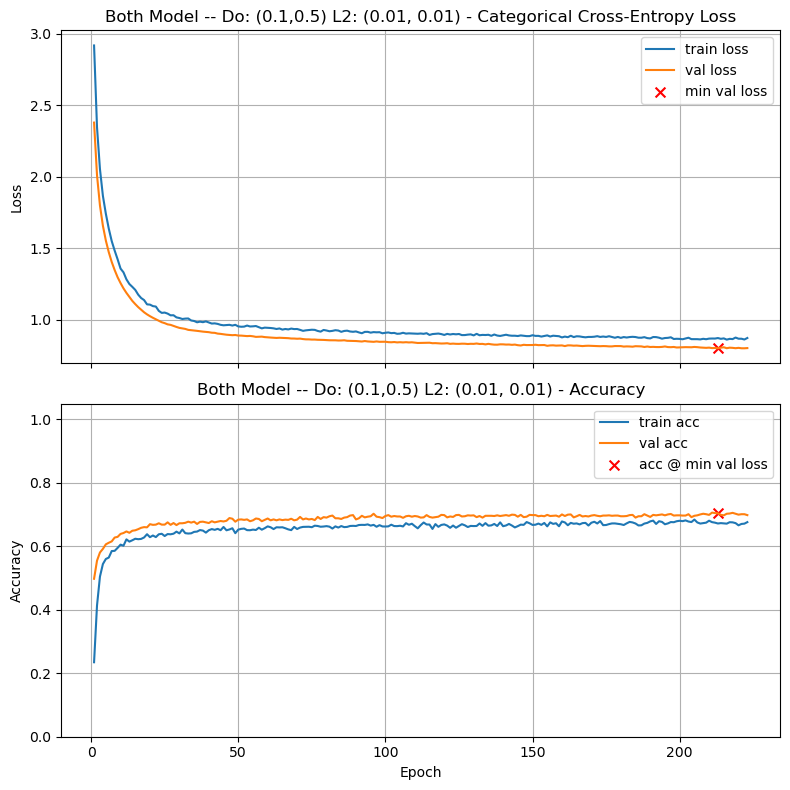

Final Training Loss:            0.8706
Final Training Accuracy:        0.6764
Final Validation Loss:          0.8000
Final Validation Accuracy:      0.6986
Minimum Validation Loss:        0.7986 (Epoch 213)
Validation Accuracy @ Min Loss: 0.7043

Test Loss: 0.8244
Test Accuracy: 0.6807

Validation-Test Gap (accuracy): 0.023571

Execution Time: 00:02:40

Both Model -- Do: (0.1,0.5) L2: (0.0001, 0.001)



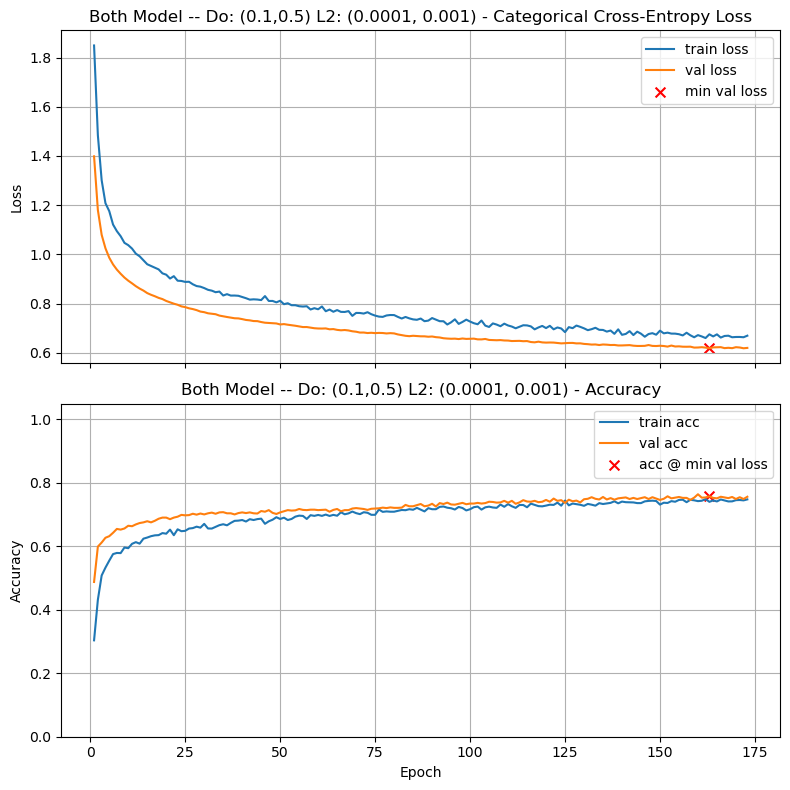

Final Training Loss:            0.6700
Final Training Accuracy:        0.7481
Final Validation Loss:          0.6203
Final Validation Accuracy:      0.7564
Minimum Validation Loss:        0.6188 (Epoch 163)
Validation Accuracy @ Min Loss: 0.7579

Test Loss: 0.6482
Test Accuracy: 0.7421

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:02:04


In [32]:
# Your code here

for l21 in [1e-4, 1e-3, 1e-2]:

        model_l2 = build_model(X_train.shape[1], [ (64,'tanh',l21,0.1), (32,'tanh',l21,0.5) ], n_classes)
    
        train_and_test(model_l2, lr_schedule = 0.0005, title = f"Both Model -- Do: (0.1,0.5) L2: {(l21,l21)}")


model_l2 = build_model(X_train.shape[1], [ (64,'tanh',1e-4,0.1), (32,'tanh',1e-3,0.5) ], n_classes)
    
train_and_test(model_l2, lr_schedule = 0.0005, title = f"Both Model -- Do: (0.1,0.5) L2: {(1e-4,1e-3)}")


Baseline Model -- L2: (0.0001, 0.001)



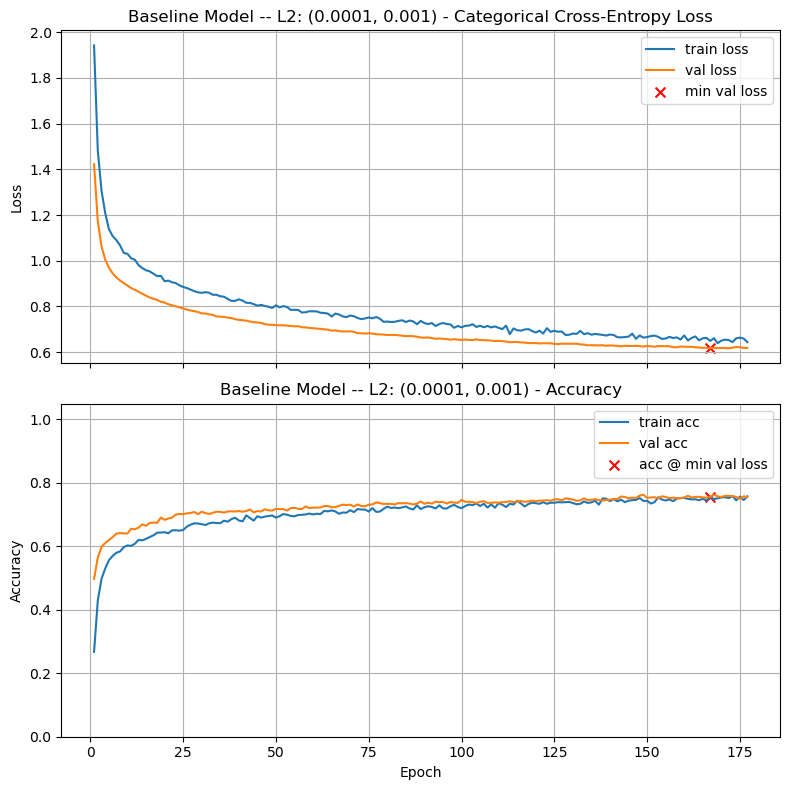

Final Training Loss:            0.6436
Final Training Accuracy:        0.7579
Final Validation Loss:          0.6186
Final Validation Accuracy:      0.7550
Minimum Validation Loss:        0.6167 (Epoch 167)
Validation Accuracy @ Min Loss: 0.7564

Test Loss: 0.6551
Test Accuracy: 0.7386

Validation-Test Gap (accuracy): 0.017857

Execution Time: 00:02:05


In [33]:
model_l2 = build_model(X_train.shape[1], [ (64,'tanh',1e-4,0.1), (32,'tanh',1e-3,0.5) ], n_classes)
    
train_and_test(model_l2, lr_schedule = 0.0005, title = f"Baseline Model -- L2: {(1e-4,1e-3)}")

In [34]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = 0.0             # Replace 0.0 with your answer
a5 = 0.7693

In [35]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5 = {a5:.4f}') 

a5 = 0.7693


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **\[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Record the **validation accuracy** of your best model and compare it with earlier results.
* Answer the graded question.


In [36]:
# Your code here


In [37]:
# Set a6 to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best validation accuracy at the epoch of minimum validation loss

a6 = (0.0,0.0)             # Replace (0.0,0.0) with your answer

In [38]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a6 = {a6}') 

a6 = (0.0, 0.0)


In [39]:
# Your code here

for dr in [0.90, 0.95, 0.99, 0.999]:
        # Define learning rate schedule
        lr_schedule = ExponentialDecay(
            initial_learning_rate=0.001,            # start higher than default
            decay_steps=len(X_train)//64,           # decay at end of each epoch
            decay_rate=dr
        )

        model_dropout = model_deep_baseline = build_model(X_train.shape[1], [ (64,'sigmoid',0.0,0.0), (32,'sigmoid',0.0,0.0)], n_classes)
        
        train_and_test(model_dropout, title = f"Exponential Decay Model -- decay {dr}",callbacks=[lr_schedule])


'\nfor dr in [0.90, 0.95, 0.99, 0.999]:\n        # Define learning rate schedule\n        lr_schedule = ExponentialDecay(\n            initial_learning_rate=0.001,            # start higher than default\n            decay_steps=len(X_train)//64,           # decay at end of each epoch\n            decay_rate=dr\n        )\n\n        model_dropout = model_deep_baseline = build_model(X_train.shape[1], [ (64,\'sigmoid\',0.0,0.0), (32,\'sigmoid\',0.0,0.0)], n_classes)\n        \n        train_and_test(model_dropout, title = f"Exponential Decay Model -- decay {dr}",callbacks=[lr_schedule])\n'

### Optional: Print out your results of all experiments

In [41]:
print_results()

Baseline Model -- L2: (0.0001, 0.0001)  	0.7779
Baseline Model -- lr: 0.0001            	0.7771
Baseline Model -- tanh                  	0.7757
Baseline Model -- L2: (0.001, 0.001)    	0.7736
Baseline Model -- lr: 0.0005            	0.7721
Baseline Model -- sigmoid               	0.7714
Baseline Model -- dropout: (0.0, 0.4)   	0.7714
Baseline Model -- dropout: (0.1, 0.3)   	0.7714
Both Model -- Do: (0.1,0.5) L2: (0.0001, 0.0001)	0.7714
Baseline Model -- dropout: (0.1, 0.5)   	0.7700
Baseline Model -- lr: 5e-05             	0.7679
Baseline Model -- lr: 0.001             	0.7664
Baseline Model -- dropout: (0.0, 0.3)   	0.7650
Baseline Model -- dropout: (0.2, 0.5)   	0.7600
Baseline Model -- dropout: (0.2, 0.3)   	0.7586
Baseline Model -- dropout: (0.2, 0.4)   	0.7586
Both Model -- Do: (0.1,0.5) L2: (0.0001, 0.001)	0.7579
Baseline Model -- L2: (0.0001, 0.001)   	0.7564
Baseline Model -- dropout: (0.1, 0.4)   	0.7529
Both Model -- Do: (0.1,0.5) L2: (0.001, 0.001)	0.7521
Baseline Model -- d

## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these. 

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?